In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("car.jpeg")

if image is None:
    print("Image not found")
else:
    print("Image loaded successfully")

Image loaded successfully


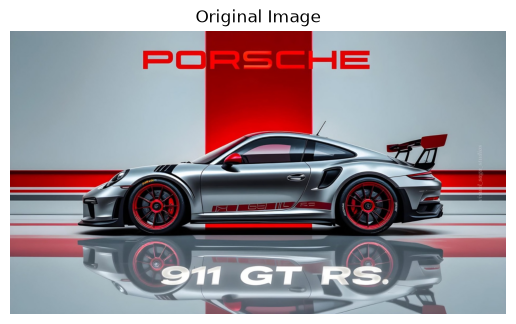

In [19]:
plt.subplot(1, 1, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.show()

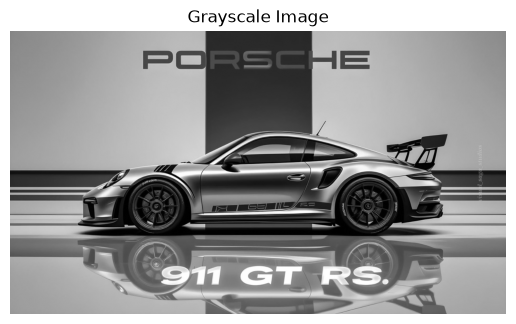

In [20]:

plt.subplot(1, 1, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

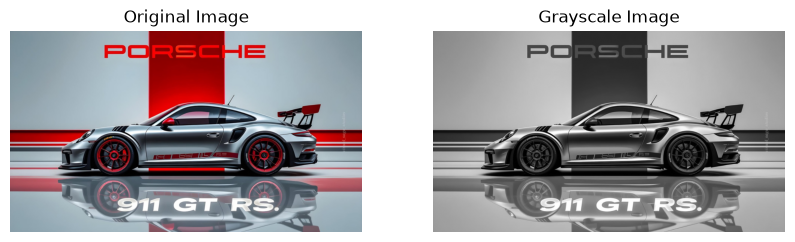

In [21]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

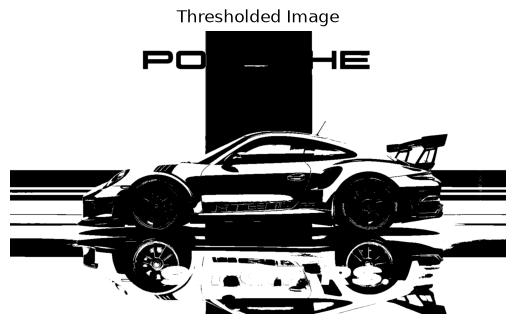

In [22]:
ret, threshold = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.imshow(threshold, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

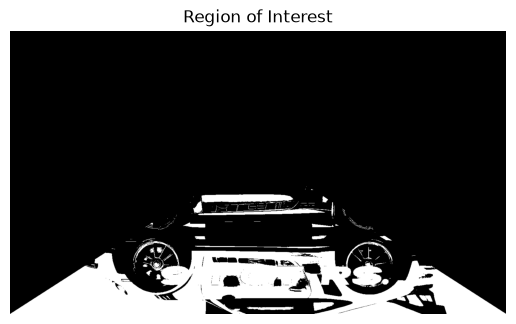

In [23]:
height, width = gray.shape

mask = np.zeros_like(gray)

polygon = np.array([[
    (0, height),
    (width, height),
    (int(width * 0.6), int(height * 0.55)),
    (int(width * 0.4), int(height * 0.55))
]], dtype=np.int32)

cv2.fillPoly(mask, polygon, 255)

roi = cv2.bitwise_and(threshold, mask)

plt.imshow(roi, cmap="gray")
plt.title("Region of Interest")
plt.axis("off")
plt.show()

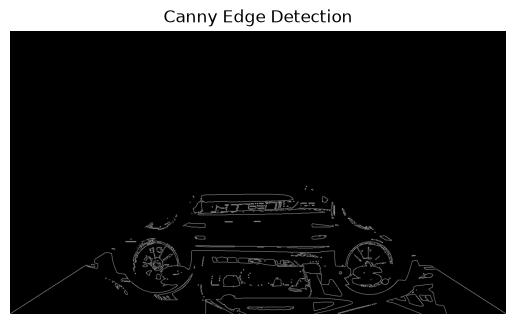

In [24]:
edges = cv2.Canny(roi, 50, 150)

plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

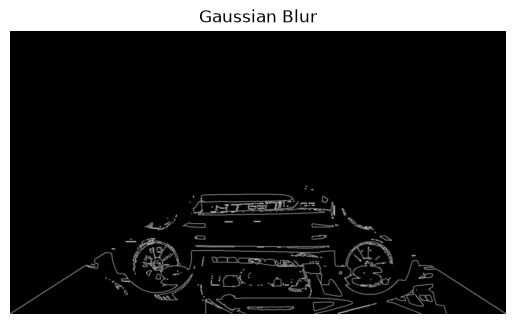

In [25]:
blur = cv2.GaussianBlur(
    edges,
    (5, 5),
    0
)

plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

In [26]:
lines = cv2.HoughLinesP(
    blur,
    1,
    np.pi / 180,
    threshold=50,
    minLineLength=50,
    maxLineGap=100
)

print("Detected Lines:", lines)

Detected Lines: [[ 326  704 1230  720]
 [ 274  733 1385  771]
 [ 417  688 1218  702]
 ...
 [1271  864 1357  861]
 [ 943  767 1189  763]
 [ 629  877  693  880]]


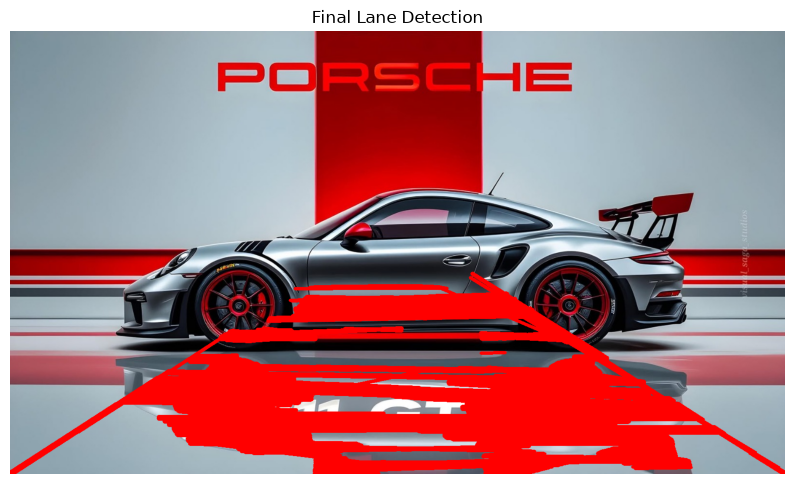

In [28]:
lane = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
).copy()

if lines is not None:

    for line in lines:

        line = np.array(line).reshape(-1)

        if len(line) == 4:

            x1, y1, x2, y2 = line

            cv2.line(
                lane,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (255, 0, 0),
                5
            )

plt.figure(figsize=(10, 6))
plt.imshow(lane)
plt.title("Final Lane Detection")
plt.axis("off")
plt.show()